In [ ]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/census-income .csv')
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
#The dataset is a demographic census dataset
#The goal is to predict whether a person earns more than $50k per year or not

In [ ]:
df.rename(columns={'annual_income':'income'},inplace=True)

In [ ]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
df['income'].value_counts()

,count
income,
<=50K,24720
>50K,7841


In [ ]:
df['workclass'].value_counts()

,count
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
?,1836
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df['native-country'].unique()

array(['United-States', 'Cuba', 'Jamaica', 'India', '?', 'Mexico',
       'South', 'Puerto-Rico', 'Honduras', 'England', 'Canada', 'Germany',
       'Iran', 'Philippines', 'Italy', 'Poland', 'Columbia', 'Cambodia',
       'Thailand', 'Ecuador', 'Laos', 'Taiwan', 'Haiti', 'Portugal',
       'Dominican-Republic', 'El-Salvador', 'France', 'Guatemala',
       'China', 'Japan', 'Yugoslavia', 'Peru',
       'Outlying-US(Guam-USVI-etc)', 'Scotland', 'Trinadad&Tobago',
       'Greece', 'Nicaragua', 'Vietnam', 'Hong', 'Ireland', 'Hungary',
       'Holand-Netherlands'], dtype=object)

In [ ]:
#Checking for null values
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
#we have to change the "?" to null values, so that we can drop it later
df=df.replace("?",np.nan) #put nan in place of ?

In [ ]:
df['workclass'].value_counts()

,count
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


In [ ]:
df.isnull().sum().sum()

np.int64(4262)

In [ ]:
(4262/32561)*100 #either drop or fill

13.08927858481005

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
df.duplicated().sum()

np.int64(23)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

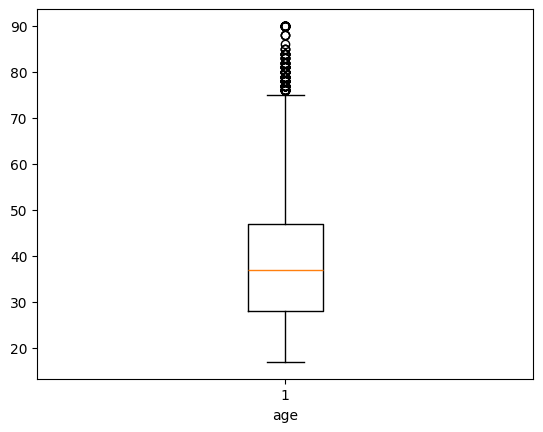

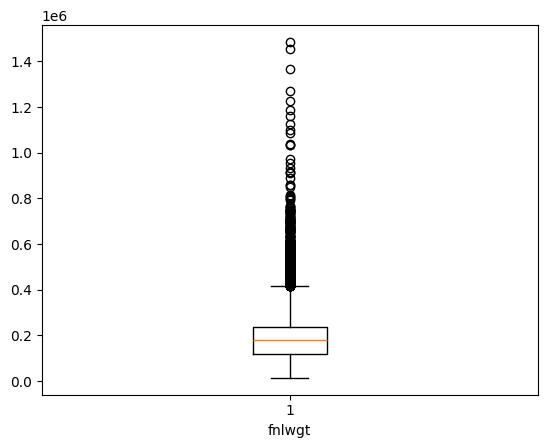

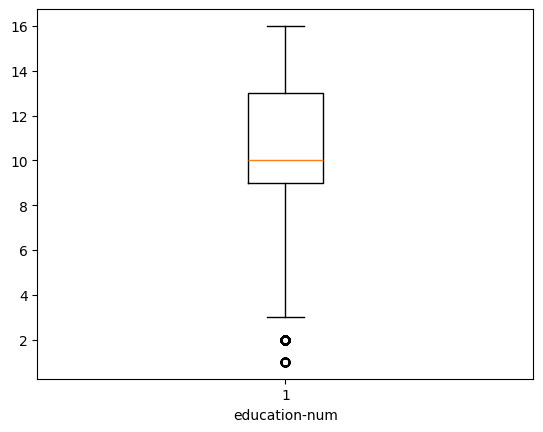

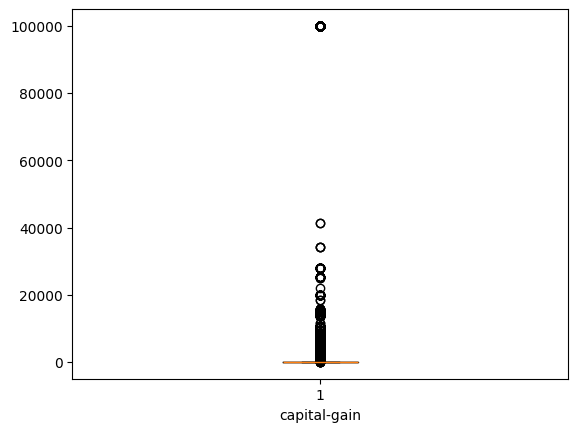

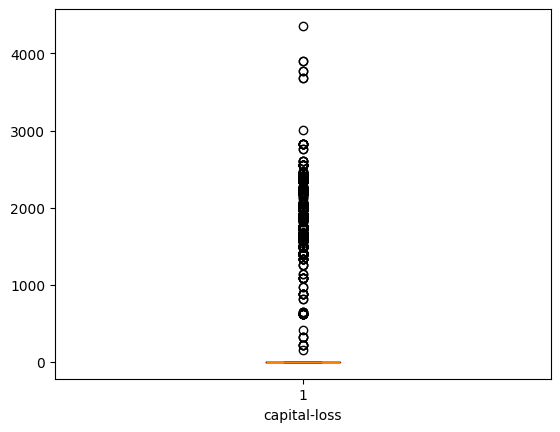

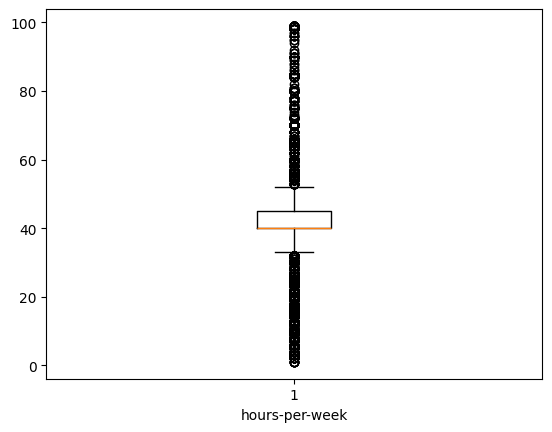

In [ ]:
#Outliers identification and removal

for col in df.columns:
  if df[col].dtype!='object':
    plt.boxplot(df[col])
    plt.xlabel(col)
    plt.show()



In [ ]:
out_list=['age','fnlwgt','education-num','hours-per-week']

for col in out_list:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)

  IQR= Q3-Q1

  LB=Q1-1.5*IQR
  UB=Q3+1.5*IQR

  df=df[(df[col]>=LB) & (df[col]<=UB)]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21317 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             21317 non-null  int64 
 1   workclass       21317 non-null  object
 2   fnlwgt          21317 non-null  int64 
 3   education       21317 non-null  object
 4   education-num   21317 non-null  int64 
 5   marital-status  21317 non-null  object
 6   occupation      21317 non-null  object
 7   relationship    21317 non-null  object
 8   race            21317 non-null  object
 9   sex             21317 non-null  object
 10  capital-gain    21317 non-null  int64 
 11  capital-loss    21317 non-null  int64 
 12  hours-per-week  21317 non-null  int64 
 13  native-country  21317 non-null  object
 14  income          21317 non-null  object
dtypes: int64(6), object(9)
memory usage: 2.6+ MB


In [ ]:
#Label Encoding : converting categorical data to numerical data

from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

for col in df.columns:
  if df[col].dtype=='object':
    df[col]=le.fit_transform(df[col])

In [ ]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,5,77516,8,13,4,0,1,4,1,2174,0,40,38,0
2,38,2,215646,10,9,0,5,1,4,1,0,0,40,38,0
3,53,2,234721,1,7,2,5,0,2,1,0,0,40,38,0
4,28,2,338409,8,13,2,9,5,2,0,0,0,40,4,0
5,37,2,284582,11,14,2,3,5,4,0,0,0,40,38,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32555,22,2,310152,13,10,4,10,1,4,1,0,0,40,38,0
32556,27,2,257302,6,12,2,12,5,4,0,0,0,38,38,0
32557,40,2,154374,10,9,2,6,0,4,1,0,0,40,38,1
32558,58,2,151910,10,9,6,0,4,4,0,0,0,40,38,0


In [ ]:
#Model Building

In [ ]:
#Perform Logistic Regression. Deadline: 12:01
#Split data into x,y
#Split data into training and testing sets
#Train the model
#Get the accuracy

In [ ]:
x=df.iloc[:,:-1] #features except income
y=df['income'] #target column

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [ ]:
#Which models can work with this dataset?
#-Logistic Regression
#-Decision Tree
#-Random Forest

In [ ]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()

model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
from sklearn.metrics import *

lr_acc=accuracy_score(y_test,y_pred)

In [ ]:
lr_acc

0.7725140712945591

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier(max_depth=8)

dt.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=8)

In [ ]:
dt_pred=dt.predict(x_test)

In [ ]:
dt_acc=accuracy_score(y_test,dt_pred)
dt_acc

0.8365384615384616

In [ ]:
#loop to check accuracy with multiple depths

depths=[1,2,3,4,5,6,7,8,9,100]
list1=[]

for x in depths:
  dt_model=DecisionTreeClassifier(max_depth=x, random_state=12)
  dt_model.fit(x_train,y_train)
  y_pred=dt_model.predict(x_test)
  acc=accuracy_score(y_test,y_pred)
  list1.append(acc)
  print("Max Depth: ",x,"accuracy: ",acc)

Max Depth:  1 accuracy:  0.7328799249530957
Max Depth:  2 accuracy:  0.8076923076923077
Max Depth:  3 accuracy:  0.823405253283302
Max Depth:  4 accuracy:  0.8285647279549718
Max Depth:  5 accuracy:  0.8287992495309568
Max Depth:  6 accuracy:  0.8379455909943715
Max Depth:  7 accuracy:  0.8374765478424016
Max Depth:  8 accuracy:  0.8358348968105066
Max Depth:  9 accuracy:  0.8334896810506567
Max Depth:  100 accuracy:  0.7868198874296435


In [ ]:
#Random Forest

from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier()

rf.fit(x_train,y_train)

RandomForestClassifier()

In [ ]:
rf_pred=rf.predict(x_test)

In [ ]:
rf_acc=accuracy_score(y_test,y_pred)

In [ ]:
rf_acc

0.7868198874296435

In [ ]:
#Decision Tree is the winner

In [ ]:
#Standardization - Scaled , mean=0, std dev=1
#Perform different models with different values
#Perform Hyper Paramater Tuning
#Fill the null values